In [1]:
import os
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
import torch.nn.functional as F

import cv2
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import DataLoader
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from sklearn.decomposition import PCA

import my_utils


from sklearn.metrics import precision_recall_curve, auc
import PATT_UNet

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

import segmentation_models_pytorch as smp


from IPython.display import display

from skimage.exposure import match_histograms

import random

In [2]:
label_path = r'core_dataset\masks'
srez_path = r'core_dataset\images'

In [3]:
def cross_datasets(datasets_prefix, train_size = 128, val_size = 40):
    train_files = []
    val_files = []
    train_flags = []
    val_flags = []
    for dataset in datasets_prefix:
        dataset_files = [
            f for f in os.listdir(label_path)
            if f.startswith(dataset)
        ]


        train_files.extend(dataset_files[:train_size])
        val_files.extend(dataset_files[train_size:train_size+val_size])
        train_flags.extend([dataset] * train_size)
        val_flags.extend([dataset] * val_size)


    train_image = []
    train_target = []

    for fname in train_files:
        label = cv2.imread(os.path.join(label_path, fname))
        srez = cv2.imread(os.path.join(srez_path, fname)).astype(float) / 255

        train_image.append(srez[:, :, 0])
        train_target.append(label[:, :, 0])


    val_image = []
    val_target = []

    for fname in val_files:
        label = cv2.imread(os.path.join(label_path, fname))
        srez = cv2.imread(os.path.join(srez_path, fname)).astype(float) / 255

        val_image.append(srez[:, :, 0])
        val_target.append(label[:, :, 0])

    return {"train_image": train_image,
            "train_target": train_target,
            "train_flags": train_flags,
            "val_image": val_image,
            "val_target": val_target,
            "val_flags": val_flags,
            }

In [4]:
req_size = 512
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomRotate90(p=0.5),

    A.Affine(
        scale=(1.5, 4.0),
        translate_percent=0,
        rotate=0,
        p=0.4
    ),

    A.GaussianBlur(p = 0.25, sigma_limit = [0.5, 1]),
    A.GaussNoise(p = 0.3, std_range=(0.02, 0.05)),
    A.Downscale(scale_range=[0.5, 0.75], p = 0.25),

    #A.RandomResizedCrop(size = [256, 256], scale = [0.8, 1.0]),
    A.Resize(req_size, req_size),
    A.RandomBrightnessContrast(p = 1),
    # my_utils.AddBrChannel(1.4, 0.4),
    # my_utils.AddBrChannel(0.6, -0.4),
    # my_utils.MatchHistogram(ref_cdf = None, ref_bins = None),
    my_utils.CLAHEPrep(),
    A.Normalize(max_pixel_value=1.0),
], additional_targets={'target': 'mask'})
val_transform = A.Compose([
    A.Resize(req_size, req_size),
    # my_utils.AddBrChannel(1.4, 0.4),
    # my_utils.AddBrChannel(0.6, -0.4),
    # my_utils.MatchHistogram(ref_cdf = None, ref_bins = None),
    my_utils.CLAHEPrep(),
    A.Normalize(max_pixel_value=1.0),
], additional_targets={'target': 'mask'})

In [5]:
# model = PATT_UNet.PAttUNet(input_channels = 1, num_classes = 1)
# model = my_utils.MAEWithDecoder(torch.load(r'weights\MAE ViT\last.pth', weights_only=False))
model = smp.Segformer(in_channels = 1, classes = 1)  

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

Total params: 21,870,273
Trainable params: 21,870,273


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 16
num_epochs = 30
learning_rate = 2e-4
warmup_epochs = 10
test_mixup = 0.05

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / warmup_epochs
    return 1.0 

optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
    )

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lr_lambda
)

plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         
    factor=0.2,    
    patience=3,            
    min_lr=1e-8,
    threshold = 1e-3          
)

In [7]:
import numpy as np

def random_cdf(n_bins=1024, smooth=10):
    # случайные значения
    y = np.random.rand(n_bins)

    # сглаживание (иначе будет шум)
    y = np.convolve(y, np.ones(smooth)/smooth, mode='same')

    # делаем монотонным
    y = np.cumsum(y)
    y = y / y[-1]

    return y

def match_to_random_hist(image, n_bins=1024):
    img = image.flatten()

    # CDF изображения
    hist, bins = np.histogram(img, bins=n_bins, density=True)
    cdf = np.cumsum(hist)
    cdf = cdf / cdf[-1]

    # случайный CDF
    target_cdf = random_cdf(n_bins)

    # обратная функция (через интерполяцию)
    target_values = np.interp(cdf, target_cdf, bins[:-1])

    # маппинг
    matched = np.interp(img, bins[:-1], target_values)

    return matched.reshape(image.shape)

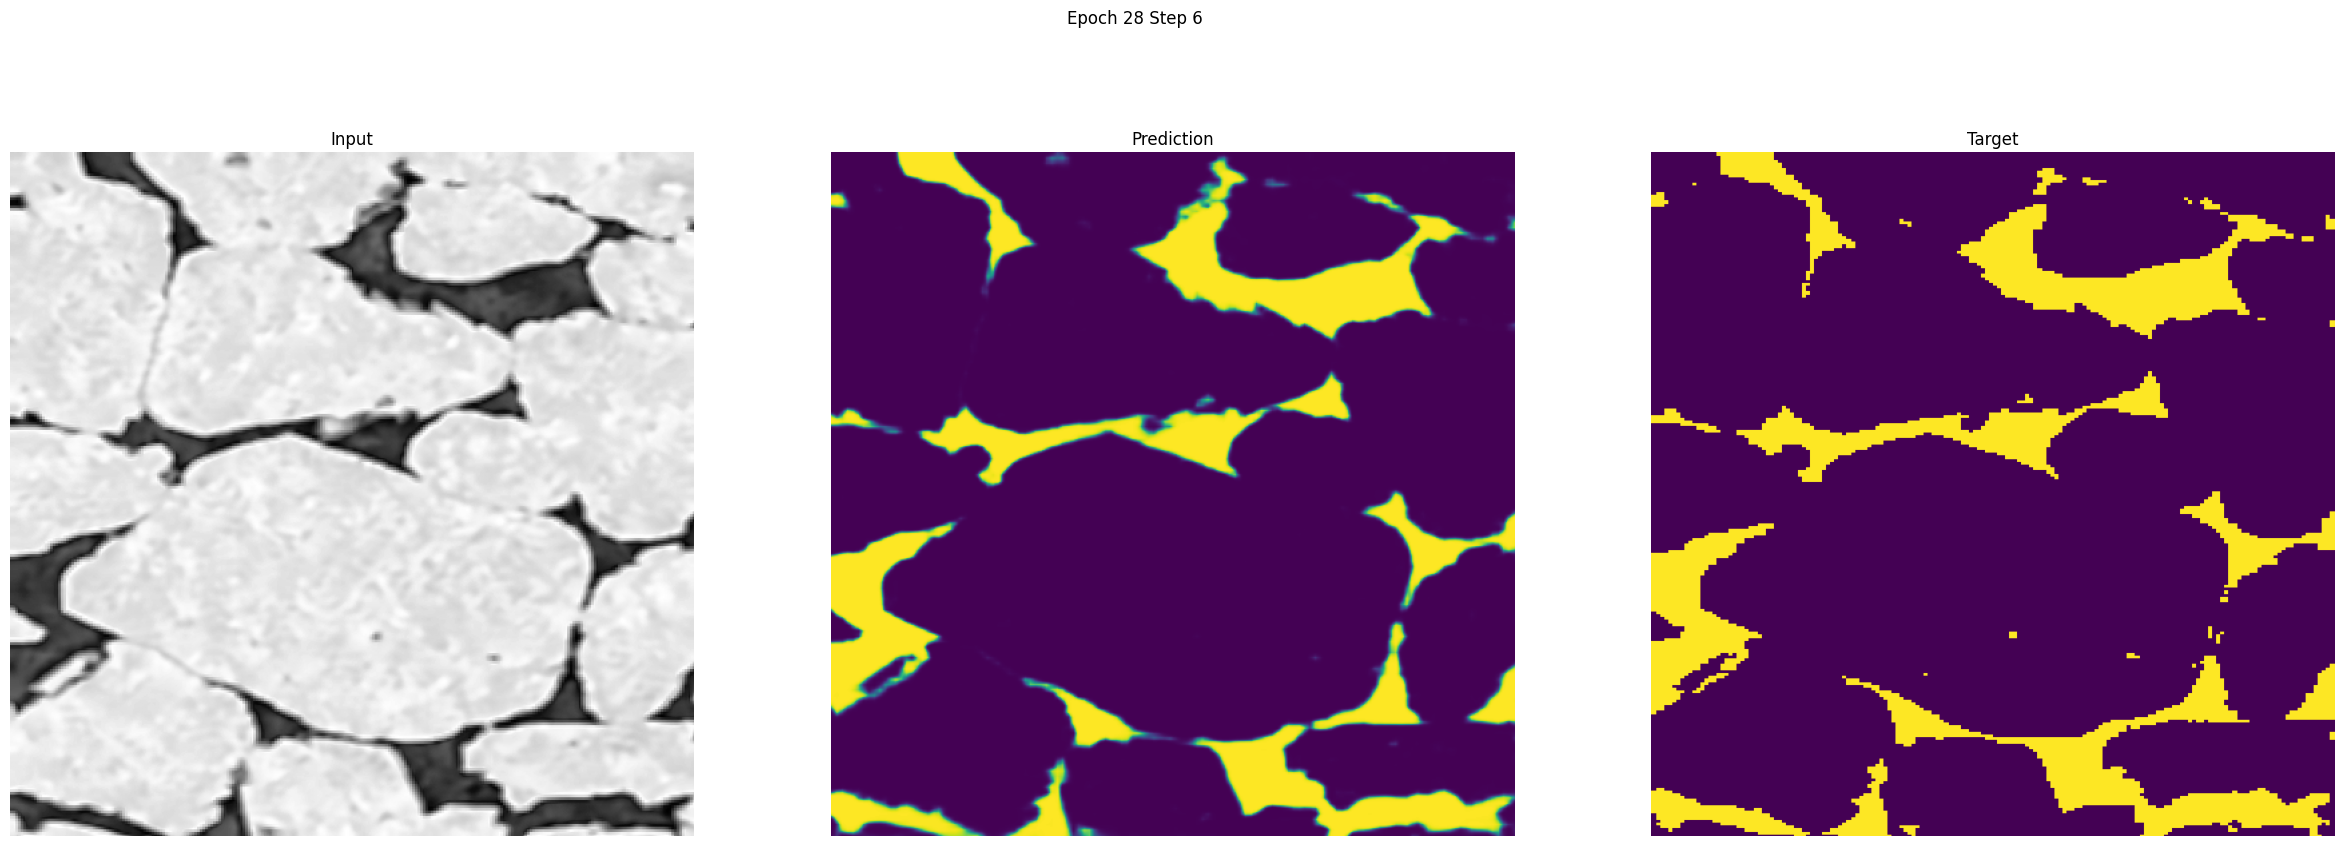

Training: 100%|██████████| 1020/1020 [1:05:46<00:00,  3.87s/batch]
8it [00:34,  4.35s/it]
Training:  94%|█████████▍| 959/1020 [1:00:33<03:51,  3.79s/batch]


KeyboardInterrupt: 

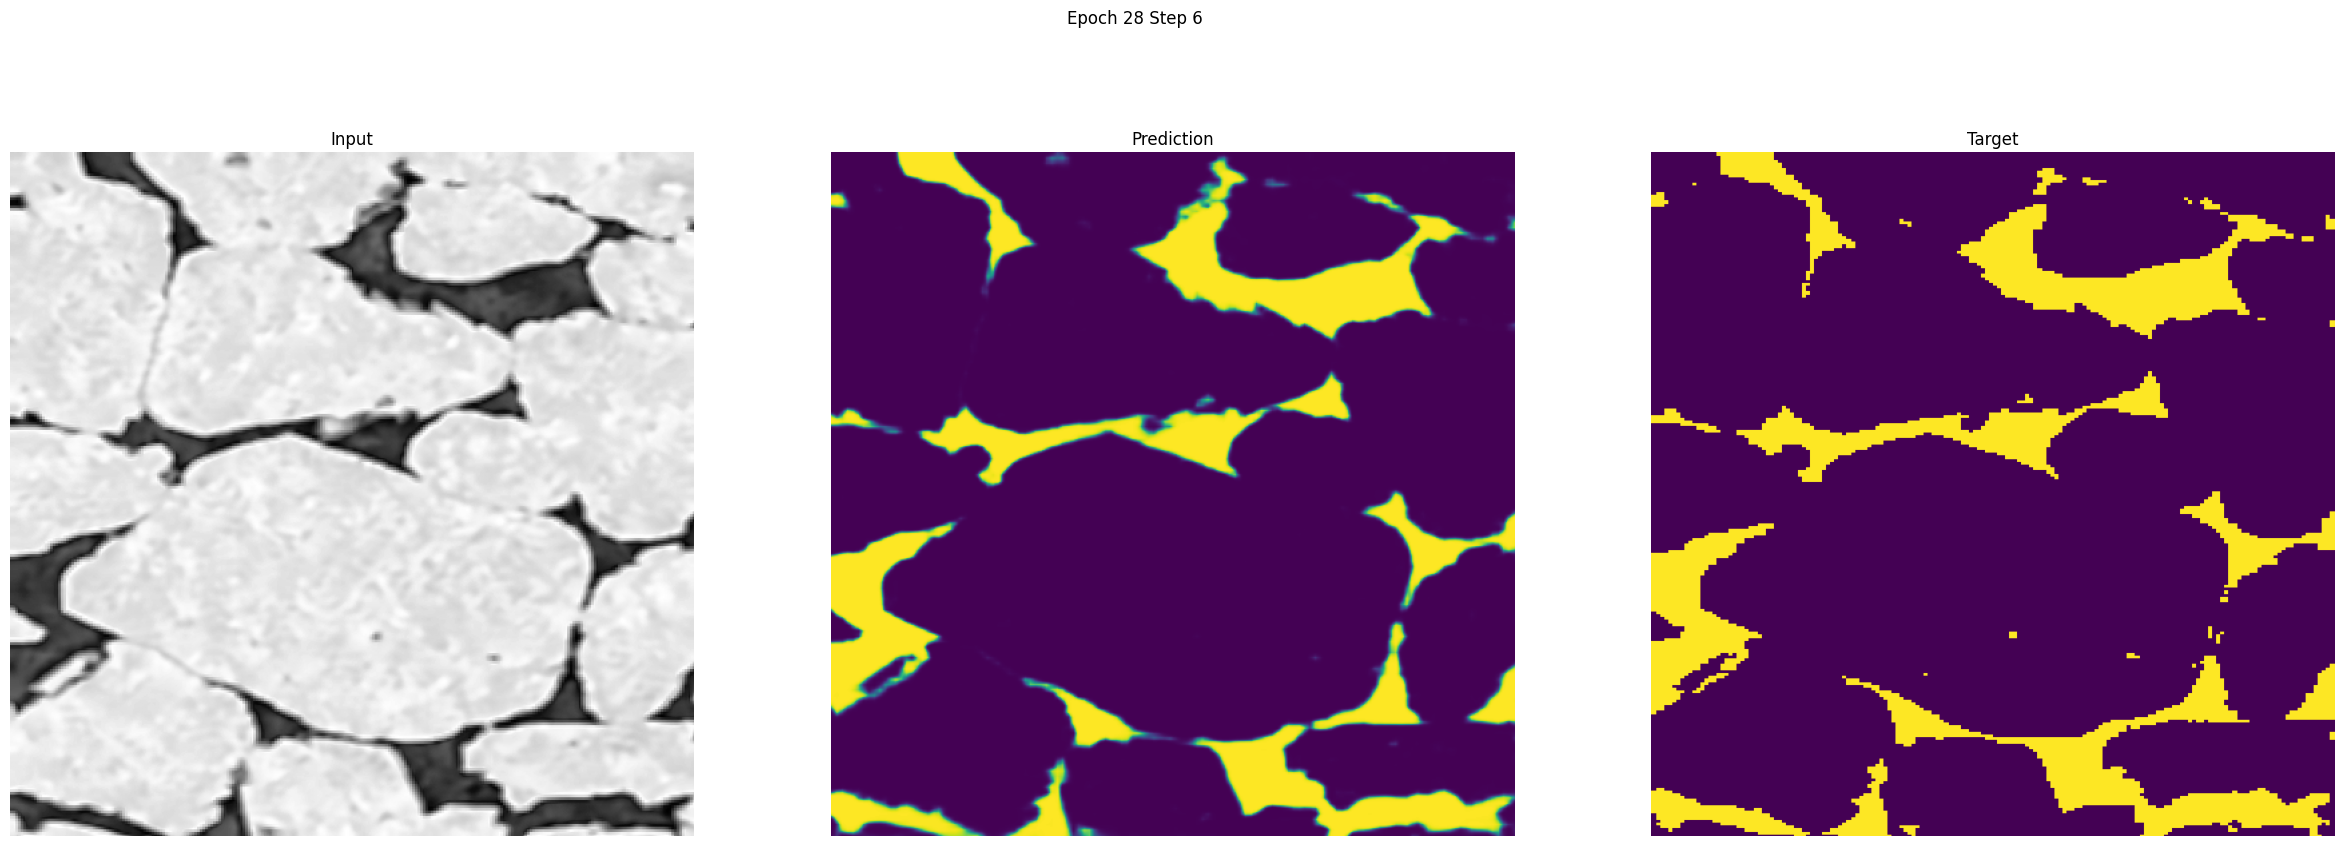

In [8]:
model.to(device)

log_dir = f"Data-mixing/SegFormer RandomContrast noise zoom CLAHE32 5% {datetime.now().strftime('%d_%m %H_%M')}"
writer = SummaryWriter(log_dir=log_dir)

loss_fn = nn.BCEWithLogitsLoss()
dice_loss = my_utils.DiceLoss()

datasets = ['Beton',
            'data3d',
            'DRP421Bentheimer',
            'DRP421Leopard',
            'DRP58',
            ]

fig, ax = plt.subplots(1, 3, figsize = (30, 10))
handle = display(fig, display_id=True)

for crossval in range(len(datasets)):
    dataset_name = datasets[crossval]

    train_list = [d for d in datasets if d != dataset_name]

    train_data = cross_datasets(train_list)
    test_data = cross_datasets([dataset_name], val_size = int(test_mixup * len(train_data['train_image'])))

    # train_volume = np.stack(train_data['train_image']).flatten()
    # hist, train_bins = np.histogram(train_volume, bins=1024, density=True)
    # train_cdf = np.cumsum(hist)
    # train_cdf = train_cdf / train_cdf[-1]

    # transform.transforms[-2].cdf = train_cdf
    # transform.transforms[-2].bins = train_bins
    # val_transform.transforms[-2].cdf = train_cdf
    # val_transform.transforms[-2].bins = train_bins

    #подмешиваем тестовые экземпляры в train
    train_data['train_image'].extend(test_data['val_image'])
    train_data['train_target'].extend(test_data['val_target'])
    train_data['train_flags'].extend(test_data['val_flags'])

    train_dataset = my_utils.CoreDataset(train_data['train_target'], train_data['train_image'], flag_list = train_data['train_flags'], transform = transform, multiply_channels = False)
    test_dataset = my_utils.CoreDataset(test_data['train_target'], test_data['train_image'], transform = val_transform, multiply_channels = False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # histogram_ref = random.choice(train_data['train_image'])

    total_batches = len(train_loader) * num_epochs
    with tqdm(total=total_batches, desc='Training', unit='batch') as pbar:

        for epoch in range(num_epochs):
            model.train()
            train_loss = 0
            for idx, batch in enumerate(train_loader):
                images = batch["image"].to(device).unsqueeze(1)    # [B, С, H, W]
                targets = batch["target"].to(device) # [B, H, W]
                flags = batch['flag']

                pred = model(images)

                # loss = loss_fn(pred, targets.unsqueeze(1)) + dice_loss(pred, targets)

                loss = 0
                for p, t, f in zip(pred, targets, flags):
                    p = p.unsqueeze(0)
                    t = t.unsqueeze(0)
                    if f == dataset_name:
                        a = 1 / (test_mixup * len(datasets))
                    else:
                        a = 1

                    loss += (loss_fn(p, t.unsqueeze(1)) + dice_loss(p, t)) * a
                loss /= batch_size
                    
                    
                train_loss += loss.item() / batch_size

                loss.backward()

                optimizer.step()
                optimizer.zero_grad()

                pbar.update(1)

                for a in ax:
                    a.clear()

                img = images[0][0].detach().cpu().squeeze()
                pred_mask = torch.sigmoid(pred[0]).detach().cpu().squeeze()
                tgt = targets[0].detach().cpu()

                ax[0].imshow(img, cmap='gray')
                ax[0].axis('off')
                ax[0].set_title('Input')
                ax[1].imshow(pred_mask)
                ax[1].axis('off')
                ax[1].set_title('Prediction')
                ax[2].imshow(tgt)
                ax[2].axis('off')
                ax[2].set_title('Target')
                
                fig.suptitle(f"Epoch {epoch} Step {idx}")

                handle.update(fig)

            train_loss /= len(train_loader)

            if epoch < warmup_epochs:
                warmup_scheduler.step()
            else:
                plateau_scheduler.step(train_loss)

            writer.add_scalar(f'Loss/Train {dataset_name}', train_loss, epoch)

            

    val_IoU = 0
    val_PRAUC = 0

    for idx, batch in tqdm(enumerate(test_loader)):

        images = batch["image"].to(device).unsqueeze(1)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]
        
        with torch.no_grad():
            pred = model(images)

        val_IoU += my_utils.compute_miou(torch.where(pred > 0.5, 1, 0), targets, num_classes = 1)

        val_PRAUC += my_utils.pr_auc_score(pred, targets)

        if idx % 4 == 0:
            B = images.size(0)
            val_fig, axes = plt.subplots(B, 3, figsize=(12, 4 * B))
            for j in range(B):
                img = images[j].squeeze().cpu().numpy()
                gt = targets[j].cpu().numpy()
                pr = pred[j].cpu().numpy().squeeze() > 0.5

                axes[j, 0].imshow(img, cmap='gray')
                axes[j, 0].set_title("Image")
                axes[j, 0].axis('off')

                axes[j, 1].imshow(gt, cmap='viridis')
                axes[j, 1].set_title("Target")
                axes[j, 1].axis('off')

                axes[j, 2].imshow(pr, cmap='viridis')
                axes[j, 2].set_title("Prediction")
                axes[j, 2].axis('off')

            plt.tight_layout()

            writer.add_figure(f'Val/Compare_batch {dataset_name}', val_fig, idx)
            plt.close(val_fig)

    val_IoU /= len(test_loader)
    val_PRAUC /= len(test_loader)

    writer.add_text(
    "metrics",
    f"{dataset_name} dataset, IoU={val_IoU:.4f}, PRAUC={val_PRAUC:.4f}",
    crossval
    )

writer.close()

In [ ]:
train_data['train_image'][0].max()

np.float64(0.9921568627450981)

In [ ]:
if len([]):
    print(1)

In [ ]:
len(test_data['train_image'])

128

In [ ]:
len(test_data['train_target']),len(test_data['train_image'])

(128, 128)

In [ ]:
my_utils.CoreDataset(test_data['train_target'], test_data['train_image'], val_transform, multiply_channels = False).flags

AttributeError: 'CoreDataset' object has no attribute 'flags'

In [ ]:
test_dataset[2]

IndexError: list index out of range

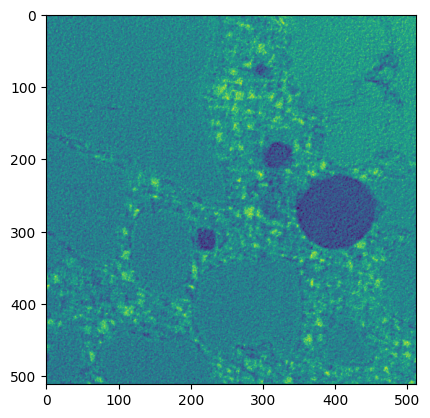

In [ ]:
plt.imshow(train_data['train_image'][-1])

[(array([[0.55294118, 0.56470588, 0.58431373, ..., 0.47058824, 0.46666667,
          0.46666667],
         [0.55686275, 0.56862745, 0.58823529, ..., 0.4745098 , 0.47058824,
          0.47058824],
         [0.56862745, 0.58039216, 0.59607843, ..., 0.47843137, 0.48235294,
          0.48235294],
         ...,
         [0.44313725, 0.45098039, 0.47058824, ..., 0.44313725, 0.44705882,
          0.44705882],
         [0.47843137, 0.48235294, 0.47843137, ..., 0.46666667, 0.47058824,
          0.47058824],
         [0.49411765, 0.49411765, 0.48235294, ..., 0.47843137, 0.48235294,
          0.48235294]], shape=(512, 512)),
  'data3d'),
 (array([[0.54117647, 0.55294118, 0.58431373, ..., 0.46666667, 0.45882353,
          0.45490196],
         [0.54117647, 0.55294118, 0.57647059, ..., 0.46666667, 0.45882353,
          0.45490196],
         [0.54117647, 0.54901961, 0.56470588, ..., 0.4745098 , 0.45882353,
          0.45098039],
         ...,
         [0.47843137, 0.4745098 , 0.47058824, ..., 0.4627

In [ ]:
loss

tensor(1.1235, device='cuda:0', grad_fn=<AddBackward0>)